In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# First attempt 
change price and keep size equal

In [2]:
mid_price = 1000
steps_price = 5
steps_number = 99
bid_size = 100

In [3]:
# Start list of bid prices with best bid
bid_prices = [mid_price-steps_price]
# Start list of bid sizes
bid_sizes = [100]

for i in range(steps_number):
    # Create next best bid as previous bid - steps_price
    bid = bid_prices[i] - steps_price*(i/steps_number)
    bid_prices.append(bid)
    # Create corresponding bid_size
    bid_sizes.append(bid_size)

# Create df
bid_book = pd.DataFrame({'bid_price':bid_prices,'bid_size':bid_sizes})

# Add cumulative sum column
bid_book['cumulative_size'] = bid_book['bid_size'].cumsum()

In [4]:
bid_book

,bid_price,bid_size,cumulative_size
0,995.000000,100,100
1,995.000000,100,200
2,994.949495,100,300
3,994.848485,100,400
4,994.696970,100,500
...,...,...,...
95,769.494949,100,9600
96,764.696970,100,9700
97,759.848485,100,9800
98,754.949495,100,9900


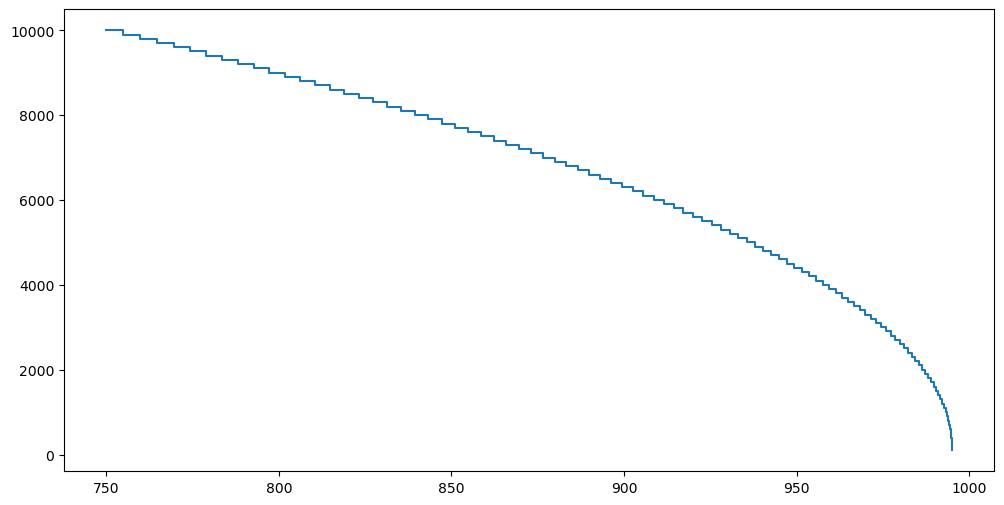

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
x = bid_book['bid_price']
y = bid_book['cumulative_size']
fig = plt.step(x,y)

Need to:

- define margin size (buy -x% of midprice, sell +y% of midprice)
- define price interval at which offers are made
- calculate necessary number of steps given price interval and margin size
- define formulae to calculate size of offer at preset price points
- Maybe define total size?
   
 or is it better to make all of equal size and change price intervals?

# Attempt 2
Define margin sizes, fixed price step difference  
Find number of steps, size of offers  

Should include 'padding' - define area to be shown and include those prices with size = 0

In [120]:
mid_price = 30_000

buy_margin, sell_margin = 0.005, 0.005
buy_depth, sell_depth = 2500, 2500

step_difference = 1

In [121]:
buy_limit = mid_price - buy_margin*mid_price
sell_limit = mid_price + sell_margin*mid_price
print(buy_limit, sell_limit)

29850.0 30150.0


In [122]:
buy_steps = int((mid_price - buy_limit)/step_difference)
buy_steps

150

In [123]:
sell_steps = int((sell_limit - mid_price)/step_difference)
sell_steps

150

In [124]:
#linear_shape
# Buy side
buy_size = buy_depth/buy_steps
print(buy_size)

# Make df with buy_steps rows and columns: price = mid-10, mid-2*10..., size = 16.67, cum_size
buy_prices = []
for i in range(buy_steps):
    bid_price = mid_price - (i+1)*step_difference
    buy_prices.append(bid_price)

buy_sizes = []
for i in range(buy_steps):
    buy_sizes.append(buy_size)
    
# sell side
sell_size = sell_depth/sell_steps
print(sell_size)

# Making list of prices and bid sizes
sell_prices = []
for i in range(sell_steps):
    bid_price = mid_price + (i+1)*step_difference
    sell_prices.append(bid_price)

sell_sizes = []
for i in range(sell_steps):
    sell_sizes.append(sell_size)


16.666666666666668
16.666666666666668


In [125]:
# Create orderbook df
buy_book = pd.DataFrame({'bid_price':buy_prices,'bid_size':buy_sizes})
sell_book = pd.DataFrame({'bid_price':sell_prices, 'bid_size':sell_sizes})

# Add cumulative sum column
buy_book['cumulative_size'] = buy_book['bid_size'].cumsum()
sell_book['cumulative_size'] = sell_book['bid_size'].cumsum()

In [126]:
buy_book

,bid_price,bid_size,cumulative_size
0,29999,16.666667,16.666667
1,29998,16.666667,33.333333
2,29997,16.666667,50.000000
3,29996,16.666667,66.666667
4,29995,16.666667,83.333333
...,...,...,...
145,29854,16.666667,2433.333333
146,29853,16.666667,2450.000000
147,29852,16.666667,2466.666667
148,29851,16.666667,2483.333333


In [127]:
sell_book

,bid_price,bid_size,cumulative_size
0,30001,16.666667,16.666667
1,30002,16.666667,33.333333
2,30003,16.666667,50.000000
3,30004,16.666667,66.666667
4,30005,16.666667,83.333333
...,...,...,...
145,30146,16.666667,2433.333333
146,30147,16.666667,2450.000000
147,30148,16.666667,2466.666667
148,30149,16.666667,2483.333333


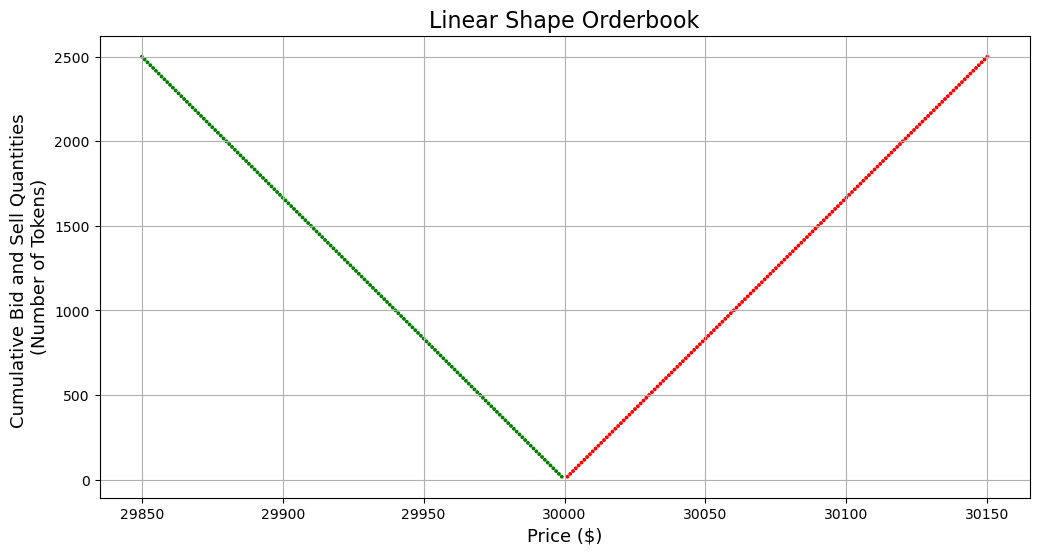

In [128]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
buy_book.sort_values(by=['bid_price'], inplace = True)
x = pd.concat([buy_book['bid_price'], sell_book['bid_price']],ignore_index=True)
y = pd.concat([buy_book['cumulative_size'], sell_book['cumulative_size']], ignore_index=True)
colors = np.where(x<mid_price, 'g', 'r')


plt.scatter(x,y, c=colors, marker='o', s=3)
plt.title("Linear Shape Orderbook", fontsize='16')
plt.xlabel("Price ($)",fontsize='13')
plt.ylabel("Cumulative Bid and Sell Quantities \n(Number of Tokens)",fontsize='13')
plt.grid()